Filename: m101.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     125   (530, 530)   int16   
  1  Photometric CALTABLE    1 BinTableHDU     39   16R x 4C   [1D, 1D, 1D, 1J]   
None
SIMPLE            = True
BITPIX            = 16
NAXIS             = 2
NAXIS1            = 530
NAXIS2            = 530
Shape: (530, 530)
Dtype: >i2
NAXIS1: 530, NAXIS2: 530
min is 1507, max is 15752, mean is 4795.924268422927, standard deviation is 1848.2526085366376, median is 4102.0, mode is 3551


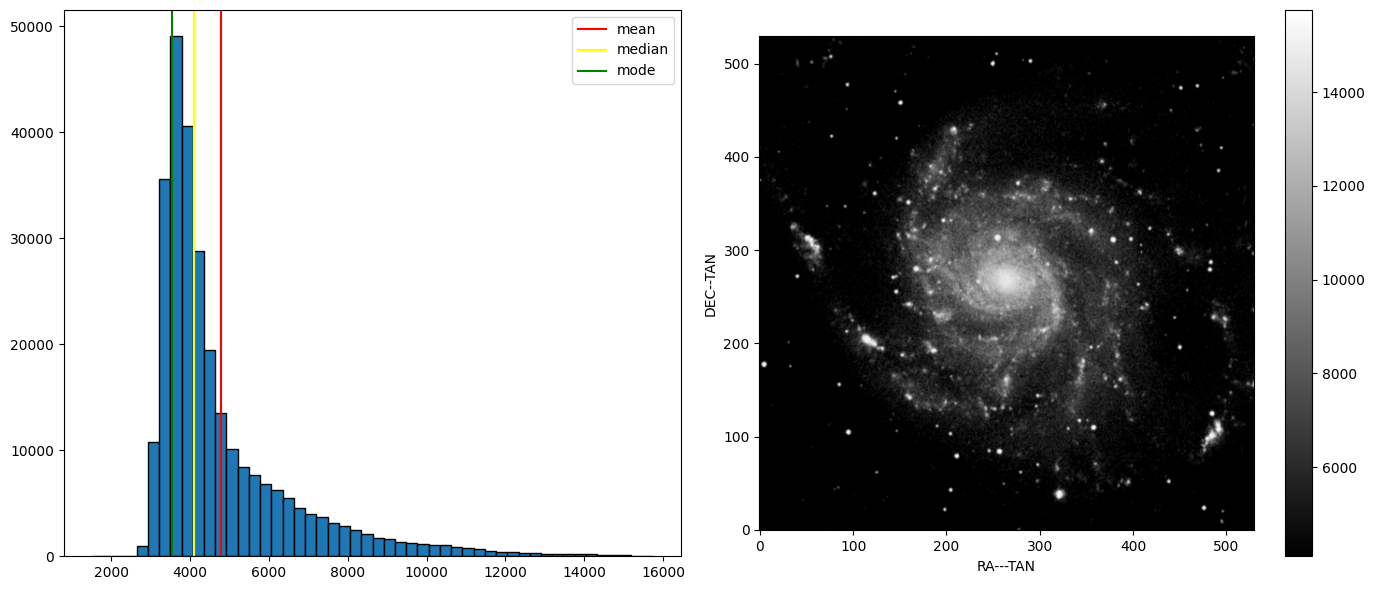

counts


In [75]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

hdulist = fits.open('m101.fits')
x=hdulist.info()
print(x)
hdr = hdulist[0].header
#print(hdr)
for key in hdr[:5]:
    print(f"{key:18s}= {hdr[key]}")
    
dat = hdulist[0].data
print(f"Shape: {dat.shape}")
print(f"Dtype: {dat.dtype}")
print(f"NAXIS1: {hdr['NAXIS1']}, NAXIS2: {hdr['NAXIS2']}")
#dtype=represents how the computer interprets the raw bytes e.g int 16, int 32, int 64

flat = dat.flatten()

d_min = np.min(flat)
d_max = np.max(flat)
d_mean = np.mean(flat)
d_std = np.std(flat)
d_mid = np.median(flat)
d_mode = stats.mode(flat, keepdims=True).mode[0]
print(f"min is {d_min}, max is {d_max}, mean is {d_mean}, standard deviation is {d_std}, median is {d_mid}, mode is {d_mode}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.hist(flat,50,edgecolor="black")
ax1.axvline(d_mean,color='red',label="mean")
ax1.axvline(d_mid,color='yellow',label="median")
ax1.axvline(d_mode,color='green',label="mode")
ax1.legend()

array = np.asarray(dat, dtype=float)
img=ax2.imshow(array, cmap='gray', origin='lower', vmin=d_mid)
ax2.set_xlabel(hdr.get('CTYPE1', 'X'))
ax2.set_ylabel(hdr.get('CTYPE2', 'Y'))
fig.colorbar(img, ax=ax2)

plt.tight_layout()
plt.show()

hdr['BUNIT']='counts'
new_hdu = fits.PrimaryHDU(data=array, header=hdr)
new_hdu.writeto('m101_float.fits', overwrite=True, output_verify='silentfix')

print(hdr['BUNIT'])

In [73]:
from astropy.io import fits
import numpy as np

hdulist = fits.open('m101.fits')
data = hdulist[0].data
slice=data[100:120,100:120]
flat=slice.flatten()
n=len(flat)
x=np.sqrt(np.mean(data**2))
print(x)
print(np.mean(flat))
print(np.std(flat))

6.644608785827525
3578.1725
256.76325232351684


In [86]:
from astropy.io import fits
import numpy as np

hd0 = fits.open('noisemap0.fits')
dat0 = hd0[0].data
hd1 = fits.open('noisemap1.fits')
dat1 = hd1[0].data
hd2 = fits.open('noisemap2.fits')
dat2 = hd2[0].data
flat0=dat0.flatten()
sd0=np.std(flat0)
flat1=dat1.flatten()
sd1=np.std(flat1)
flat2=dat2.flatten()
sd2=np.std(flat2)
print(f"std of fit0 = {sd0}, std of fit1 = {sd1}, std of fit2 = {sd2}")

stack=np.stack([dat0, dat1, dat2], axis=0)
mean = np.mean(stack, axis=0)
st_std=np.std(mean)
print(f"standard of the stacked images is {st_std}")

manual=(1/3)*np.sqrt(sd0**2+sd1**2+sd2**2)
print(f"manually calculated standard deviation of stacked images is {manual}")
difference=abs(manual-st_std)
print(f"difference between manual and calculated values is {difference}")

std of fit0 = 9.98401556679484, std of fit1 = 10.003955116338458, std of fit2 = 9.995349488722516
standard of the stacked images is 5.773191380233297
manually calculated standard deviation of stacked images is 5.770294583366139
difference between manual and calculated values is 0.002896796867157825


In [2]:
from astropy.io import fits
import numpy as np
from astropy.table import Table

hdul = fits.open('APOGEE_stars.fits')
# Access the primary data (in this case, it is a Table)
data = hdul[1].data  # Often, the first extension contains the table
data_table=Table(data)
colnames = hdul[1].columns.names # List of the column names
mask = (
    (data_table['STARFLAG'] == 0) &
    (data_table['ASPCAPFLAG'] == 0) &
    (data_table['SNR'] > 10) &
    (data_table['GAIAEDR3_PARALLAX'] / data_table['GAIAEDR3_PARALLAX_ERROR'] > 5) &
    (~np.isnan(data_table['GAIAEDR3_PHOT_G_MEAN_MAG'])) &
    (~np.isnan(data_table['GAIAEDR3_PHOT_BP_MEAN_MAG'])) 
    &(~np.isnan(data_table['GAIAEDR3_PHOT_RP_MEAN_MAG'])))

mask2=(data_table['GAIAEDR3_PARALLAX']>0)

#data_table['DATAFLAG'] = 0
#data_table['DATAFLAG'][mask] = 1

data_table['DATAFLAG']=np.where(mask,1,0)

mg=data_table['GAIAEDR3_PHOT_G_MEAN_MAG']
parallax=np.where(mask2,data_table['GAIAEDR3_PARALLAX'],np.nan)

MG=mg+5*np.log10(parallax/1000)+5
#MG[data_table['DATAFLAG'] == 0] = -1.0
MG=np.where(data_table['DATAFLAG'] == 0,-1.0,MG)
data_table['MG']=MG
data_table.write('APOGEE_update.fits', overwrite=True)
print(data_table)

GAIAEDR3_PARALLAX GAIAEDR3_PARALLAX_ERROR ... DATAFLAG     MG   
----------------- ----------------------- ... -------- ---------
              nan                     nan ...        0      -1.0
       0.28544167                0.019475 ...        0      -1.0
       0.08209286                0.315081 ...        0      -1.0
        1.2985312              0.00952245 ...        0      -1.0
        1.2985312              0.00952245 ...        1 2.7881622
      -0.02394128               0.0450072 ...        0      -1.0
        1.3863556               0.0175672 ...        1 2.9852724
              ...                     ... ...      ...       ...
         4.132398                0.015343 ...        0      -1.0
      0.057267956               0.0597211 ...        0      -1.0
        1.4367273               0.0213831 ...        0      -1.0
       0.42296618               0.0192445 ...        0      -1.0
       0.33459017               0.0153441 ...        0      -1.0
      0.018226827        

42489404.0
    source_id         ra  ra_error       dec  dec_error  phot_g_mean_flux  \
64   17418337  235.84286  0.005008  11.71101    0.00445        42489404.0   

    phot_g_mean_flux_error  phot_g_mean_mag  phot_bp_mean_flux  \
64                5649.703         6.617699         15722506.0   

    phot_bp_mean_flux_error  phot_bp_mean_mag  phot_rp_mean_flux  \
64                 9947.167          7.360095         31655918.0   

    phot_rp_mean_flux_error  phot_rp_mean_mag  a_g_val  e_bp_min_rp_val  
64                20056.184          6.010764      0.0              0.0  


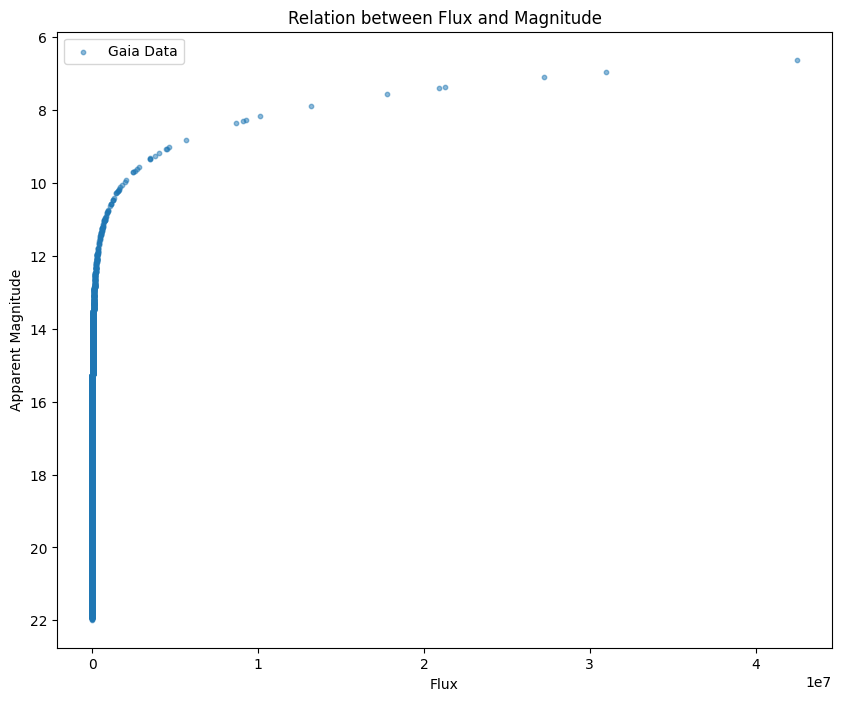

25.68840037029544


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

csv = pd.read_csv('gaiaTestData.csv')
max_flux=csv['phot_g_mean_flux'].max()
print(max_flux)
flux_row=csv[csv['phot_g_mean_flux']==max_flux]
print(flux_row)
csv_sort=csv.sort_values(by='phot_g_mean_flux')

fig,ax=plt.subplots(figsize=(10,8))
ax.scatter(csv_sort['phot_g_mean_flux'], csv_sort['phot_g_mean_mag'],alpha=0.5, s=10, label='Gaia Data')
ax.set_xlabel('Flux')
ax.set_ylabel('Apparent Magnitude')
ax.set_title('Relation between Flux and Magnitude')
ax.invert_yaxis()
ax.legend()
plt.show()

m_0=csv['phot_g_mean_mag'] + 2.5 * np.log10(csv['phot_g_mean_flux'])
print(np.mean(m_0))


In [26]:
from astroquery.gaia import Gaia
import pandas as pd
from astropy.table import Table

query = """
SELECT TOP 50
    source_id, ra, dec, parallax, parallax_error, 
    phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag
FROM gaiadr3.gaia_source
WHERE parallax / parallax_error > 5
  AND phot_g_mean_mag IS NOT NULL
  AND phot_bp_mean_mag IS NOT NULL
  AND phot_rp_mean_mag IS NOT NULL
  ORDER BY random_index
"""
job = Gaia.launch_job(query)
table=job.get_results()
df=table.to_pandas()
print(df.head())

table.write('astroquery_gaia.fits', format='fits', overwrite=True)

             SOURCE_ID          ra        dec  parallax  parallax_error  \
0  4267180339403392768  286.716913   0.276195  1.084924        0.033431   
1  6709252873623174016  276.691194 -46.105121  0.206682        0.040105   
2  4040949706019490560  265.229363 -36.358205  0.352725        0.029665   
3  4517539583701880064  284.025662  18.403039  0.674962        0.040008   
4  1823532754729083392  300.805804  20.601006  0.886435        0.020054   

   phot_g_mean_mag  phot_bp_mean_mag  phot_rp_mean_mag  
0        15.244129         15.942071         14.419943  
1        15.840754         16.380306         15.151749  
2        14.802705         16.118845         13.680644  
3        16.073896         16.652264         15.347014  
4        14.375696         14.782262         13.795675  


In [29]:
class Fibonacci:
    """Class for calculating Fibonacci sequence"""

    def get_nth_term(self, n):
        if n <= 0: return 0
        if n == 1: return 1
        
        n1, n2 = 0, 1
        for _ in range(2, n + 1):
            n1, n2 = n2, n1 + n2
        return n2

    def get_divisible_terms(self, n, m):
        divisible_list = []
        n1, n2 = 0, 1
        
        for i in range(n):
            if n1 % m == 0:
                divisible_list.append(n1)
            
            n1, n2 = n2, n1 + n2
            
        return divisible_list

fib_tool = Fibonacci()

N = 100
M = 7

nth_term = fib_tool.get_nth_term(N)

divisible_terms = fib_tool.get_divisible_terms(N, M)

print(f"The {N}-th Fibonacci term is: {nth_term}")
print(f"Fibonacci numbers divisible by {M}: {divisible_terms}")

The 100-th Fibonacci term is: 354224848179261915075
Fibonacci numbers divisible by 7: [0, 21, 987, 46368, 2178309, 102334155, 4807526976, 225851433717, 10610209857723, 498454011879264, 23416728348467685, 1100087778366101931, 51680708854858323072]
